In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
iris = load_iris()
df= pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [4]:
#std dize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [6]:
#find optimal no.s of clusters elbo
wcss = []
K = range(1,11)
for k in K:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

In [7]:
#let elbo k=3
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [8]:
#add cluster labels to orginal df
df['Cluster']= clusters

In [9]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1


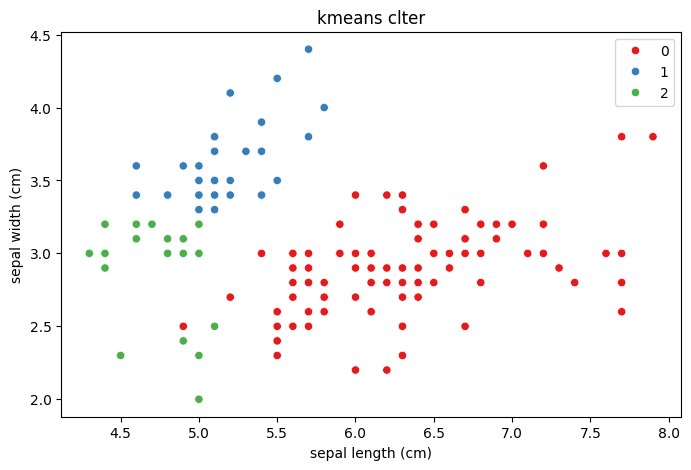

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df[iris.feature_names[0]],
                y=df[iris.feature_names[1]],hue=df['Cluster'], palette='Set1')
plt.title('kmeans clter')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.show()

In [11]:
# silhouette_score
score= silhouette_score(scaled_data,clusters)
print(score)

0.4798814508199817
